Name: Aakrit Pahadi 
Roll no: ACEO80BCT002
AI LAB 4 (Linear Regression using Pytorch)

Objectives:
1.To understand how to implement a Linear Regression model using PyTorch.
2.To learn the process of training a machine learning model using loss functions and optimizers.
3.To evaluate and visualize model performance using training/testing data and prediction graphs.

Theory:
The theory requires the use of the necessary libraries. The PyTorch library is used for building and training machine learning models while Matplotlib is used for visualizing data.

In [29]:
# Import PyTorch and matplotlib
import torch
import matplotlib.pyplot as plt

# Check PyTorch version
torch.__version__

'2.12.0+cpu'

Theory:
This cell checks whether a GPU (CUDA) is available. If available, computations can be performed faster using the GPU; otherwise, the CPU is used.

In [30]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


Theory:
The dataset is loaded using Pandas from a CSV file. Data loading is the first step in any machine learning task as it provides the input features and target values.

In [31]:
import pandas as pd
import torch

df = pd.read_csv(r'assignment-data.csv')
df.head(6)

,x,y
0,0.0,2.00
1,0.2,2.12
2,0.4,2.48
3,0.6,3.08
4,0.8,3.92
5,1.0,5.00


Theory:
The input and output values are converted into PyTorch tensors. The dataset is then divided into training data (80%) and testing data (20%) to evaluate model performance on unseen data.

In [32]:
# convert to torch tensors for use in the notebook
X = torch.tensor(df['x'].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df['y'].values, dtype=torch.float32).unsqueeze(1)
print(X.shape)
print(y.shape)
torch.Size([50, 1])
torch.Size([50, 1])
# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

torch.Size([50, 1])
torch.Size([50, 1])


(40, 40, 10, 10)

Theory:
A custom function is created to visualize training data, testing data, and predicted values. Visualization helps in understanding model behavior and prediction accuracy.

In [33]:
def plot_predictions(train_data=X_train, 
                     train_labels=y_train, 
                     test_data=X_test, 
                     test_labels=y_test, 
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

Theory:
This cell calls the plotting function to display the training and testing data points before model training.

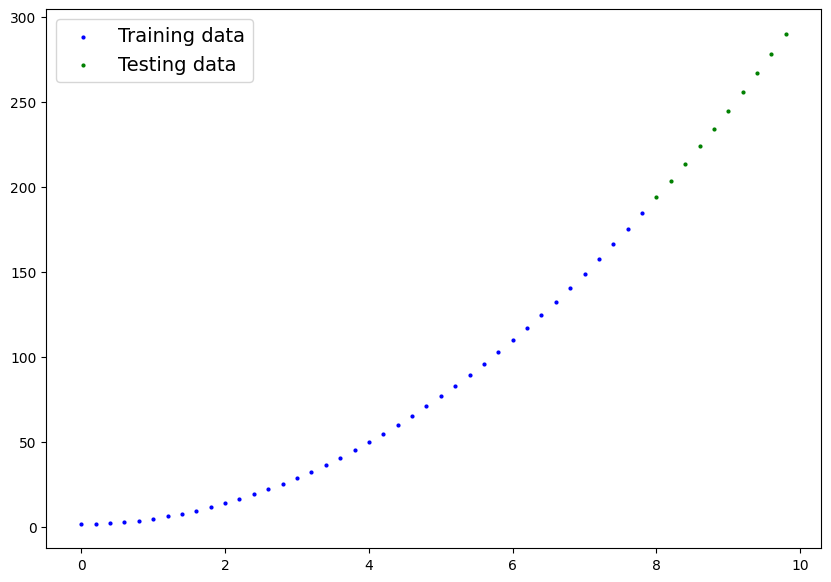

In [35]:
# Note: If you've reset your runtime, this function won't work, 
# you'll have to rerun the cell above where it's instantiated.
plot_predictions(X_train, y_train, X_test, y_test)

Theory:
A Linear Regression model is defined using PyTorch's nn.Module. The model contains learnable parameters: weight and bias, which are adjusted during training.

In [36]:
# Create a Linear Regression model class
import torch
from torch import nn
class LinearRegressionModel(nn.Module): # <- almost everything in PyTorch is a nn.Module (think of this as neural network lego blocks)
    def __init__(self):
        super().__init__() 
        self.weights = nn.Parameter(torch.randn(1, # <- start with random weights (this will get adjusted as the model learns)
                                                dtype=torch.float), # <- PyTorch loves float32 by default
                                   requires_grad=True) # <- can we update this value with gradient descent?)

        self.bias = nn.Parameter(torch.randn(1, # <- start with random bias (this will get adjusted as the model learns)
                                            dtype=torch.float), # <- PyTorch loves float32 by default
                                requires_grad=True) # <- can we update this value with gradient descent?))

    # Forward defines the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor: # <- "x" is the input data (e.g. training/testing features)
        return self.weights * x + self.bias # <- this is the linear regression formula (y = m*x + b)

Theory:
The model is instantiated and initialized with random values. A manual seed is set to ensure reproducible results.

In [37]:
# Set manual seed since nn.Parameter are randomly initialized
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module that contains nn.Parameter(s))
model_0 = LinearRegressionModel()

# Check the nn.Parameter(s) within the nn.Module subclass we created
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

Theory:
This cell verifies the data types of model parameters. PyTorch commonly uses float32 for efficient numerical computations.

In [38]:
print(model_0.weights.dtype)
print(model_0.bias.dtype)
torch.float32
torch.float32

torch.float32
torch.float32


torch.float32

Theory:
The model makes predictions on the test data before training. These predictions are generally inaccurate because the model parameters have not yet been optimized.

In [39]:

# Make predictions with model
with torch.inference_mode(): 
    y_preds = model_0(X_test)

# Note: in older PyTorch code you might also see torch.no_grad()
# with torch.no_grad():
#   y_preds = model_0(X_test)

y_preds[:5]

tensor([[2.8223],
        [2.8897],
        [2.9570],
        [3.0243],
        [3.0917]])

Theory:
This cell demonstrates how predictions are stored and displayed. It helps verify the model's output structure and dimensions.

In [40]:
import torch

# Example data
X_test = torch.arange(10).reshape(-1, 1)

y_preds = torch.tensor([
    [0.3982],
    [0.4049],
    [0.4116],
    [0.4184],
    [0.4251],
    [0.4318],
    [0.4386],
    [0.4453],
    [0.4520],
    [0.4588]
])

# Check the predictions
print(f"Number of testing samples: {len(X_test)}")
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 10
Number of predictions made: 10
Predicted values:
tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])


Theory:
The predicted values are visualized against the actual data to observe the model's initial performance.

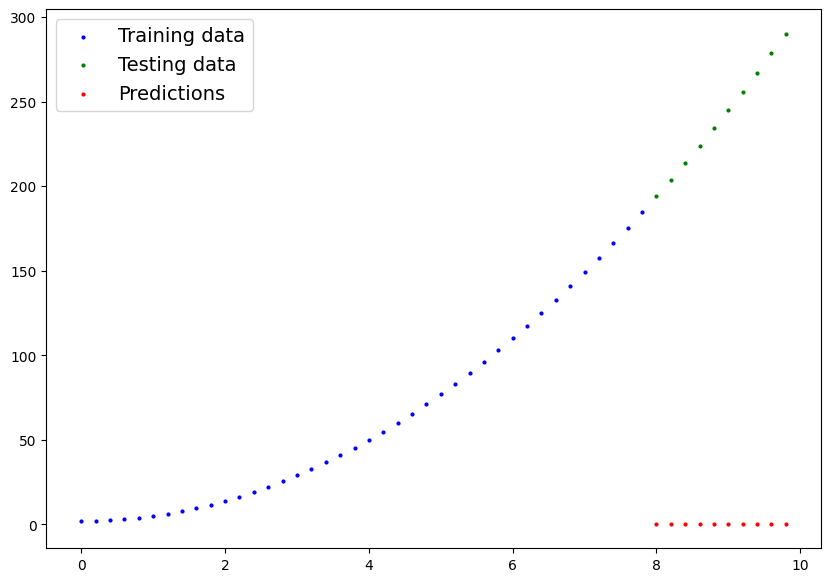

In [41]:
plot_predictions(predictions=y_preds)

Theory:
The Mean Absolute Error (MAE) loss function measures prediction error, while Stochastic Gradient Descent (SGD) updates model parameters to minimize the loss.

In [42]:
# Loss Function Selection
from torch import nn # nn contains all of PyTorch's building blocks for neural networks

# Create the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss

# Create the optimizer
optimizer = torch.optim.SGD(
                    params=model_0.parameters(), # parameters of target model to optimize
                    lr=0.01) # learning rate (how much the optimizer should change parameters at each step, higher=more (less stable), lower=less (might take a long time))

Theory:
This is the core training process. The model performs forward propagation, calculates loss, computes gradients using backpropagation, and updates parameters over multiple epochs.

In [43]:
torch.manual_seed(42)

# Set the number of epochs (how many times the model will pass over the training data)
epochs = 100

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside 
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Caculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Print out what's happening every 10 epochs
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 62.17809295654297 | MAE Test Loss: 238.7906036376953 
Epoch: 10 | MAE Train Loss: 60.557098388671875 | MAE Test Loss: 236.9355926513672 
Epoch: 20 | MAE Train Loss: 58.93609619140625 | MAE Test Loss: 235.08056640625 
Epoch: 30 | MAE Train Loss: 57.315101623535156 | MAE Test Loss: 233.2255859375 
Epoch: 40 | MAE Train Loss: 55.694091796875 | MAE Test Loss: 231.37057495117188 
Epoch: 50 | MAE Train Loss: 54.073097229003906 | MAE Test Loss: 229.5155792236328 
Epoch: 60 | MAE Train Loss: 52.45208740234375 | MAE Test Loss: 227.6605682373047 
Epoch: 70 | MAE Train Loss: 50.831092834472656 | MAE Test Loss: 225.80557250976562 
Epoch: 80 | MAE Train Loss: 49.21009063720703 | MAE Test Loss: 223.95059204101562 
Epoch: 90 | MAE Train Loss: 47.637943267822266 | MAE Test Loss: 222.1274871826172 


Theory:
Training and testing losses are plotted to observe learning progress. Decreasing loss indicates successful model training.

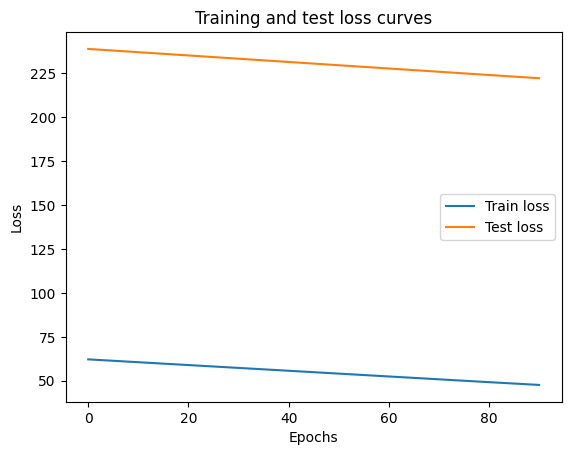

In [45]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

Theory:
The final weight and bias values learned by the model are displayed and compared with the original values.

In [46]:
# Find our model's learned parameters
print("The model learned the following values for weights and bias:")
print(model_0.state_dict())
print("\nAnd the original values for weights and bias are:")
print(f"weights: 0.7, bias: 0.3")

The model learned the following values for weights and bias:
OrderedDict([('weights', tensor([4.2199])), ('bias', tensor([1.1033]))])

And the original values for weights and bias are:
weights: 0.7, bias: 0.3


Theory:
The trained model is evaluated on test data to generate final predictions. Evaluation mode disables gradient calculations, making inference more efficient.

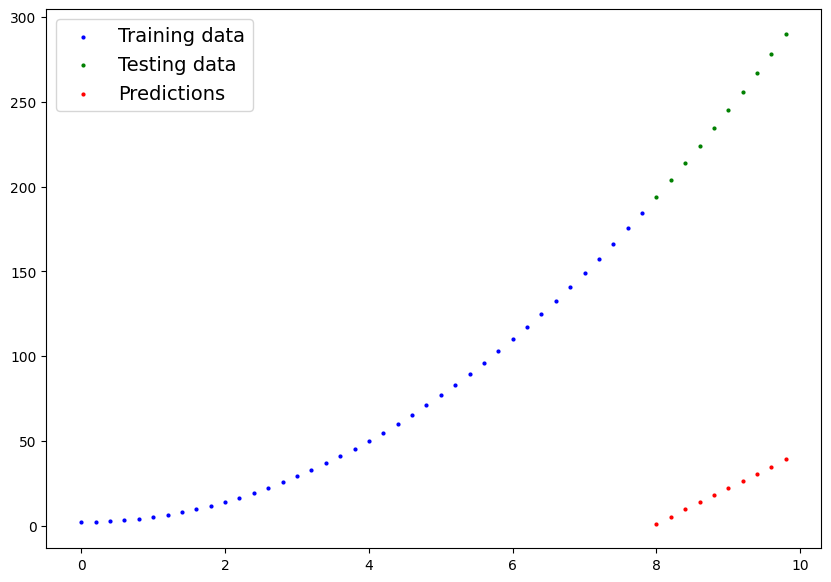

In [47]:
# 1. Set the model in evaluation mode
model_0.eval()

# 2. Setup the inference mode context manager
with torch.inference_mode():
  # 3. Make sure the calculations are done with the model and data on the same device
  # in our case, we haven't setup device-agnostic code yet so our data and model are
  # on the CPU by default.
  # model_0.to(device)
  # X_test = X_test.to(device)
  y_preds = model_0(X_test)
plot_predictions(predictions=y_preds)

In [ ]:
## For New Dataset

Theory:
Necessary libraries are imported again to ensure all dependencies are available for the new experiment.

In [60]:
import torch
from torch import nn
import pandas as pd
import matplotlib.pyplot as plt

Theory:
A new dataset is loaded from another CSV file. This dataset is used to test a more complex model.

In [61]:
df = pd.read_csv("assignment-data2.csv")

print(df.head())

     x       y
0 -9.8  673.28
1 -9.6  646.12
2 -9.4  619.52
3 -9.2  593.48
4 -9.0  568.00


Theory:
The input and output data are transformed into PyTorch tensors for model training.

In [62]:
X = torch.tensor(df["x"].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df["y"].values, dtype=torch.float32).unsqueeze(1)

Theory:
The dataset is divided into training and testing sets to assess the model's generalization capability.

In [63]:
train_split = int(0.8 * len(X))

X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

Theory:
A plotting function is created to visualize data and future model predictions.

In [64]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):

    plt.figure(figsize=(10, 7))

    # Training data
    plt.scatter(train_data, train_labels, c="b", s=5, label="Training data")

    # Test data
    plt.scatter(test_data, test_labels, c="g", s=5, label="Testing data")

    # Predictions (if available)
    if predictions is not None:
        plt.scatter(test_data, predictions, c="r", s=5, label="Predictions")

    plt.legend()
    plt.show()

Theory:
The loaded dataset is visualized to understand its pattern before training.

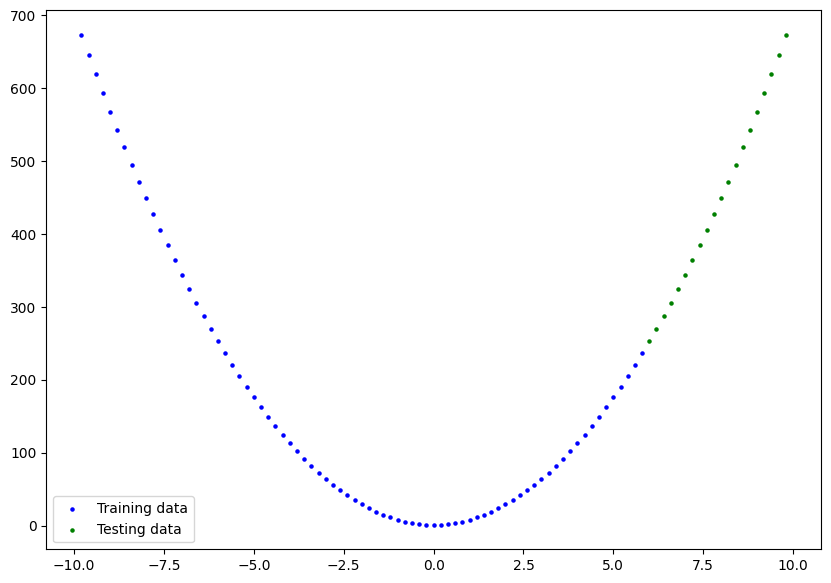

In [65]:
plot_predictions()

Theory:
A neural network with hidden layers and ReLU activation functions is defined. Unlike linear regression, this model can learn complex non-linear relationships.

In [66]:
class NonLinearModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(1, 16)
        self.layer2 = nn.Linear(16, 16)
        self.layer3 = nn.Linear(16, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.layer3(x)
        return x

Theory:
The neural network model is instantiated and initialized with random parameters.

In [67]:
torch.manual_seed(42)

model = NonLinearModel()

Theory:
Mean Squared Error (MSE) is used as the loss function, and the Adam optimizer is selected for faster and more efficient training.

In [68]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

Theory:
The model is trained for 2000 epochs. During each epoch, predictions are generated, loss is calculated, gradients are computed, and weights are updated.

In [69]:
epochs = 2000

train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):

    model.train()

    y_pred = model(X_train)

    loss = loss_fn(y_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()

    with torch.inference_mode():
        test_pred = model(X_test)
        test_loss = loss_fn(test_pred, y_test)

    if epoch % 100 == 0:
        epoch_count.append(epoch)
        train_loss_values.append(loss.item())
        test_loss_values.append(test_loss.item())

        print(f"Epoch {epoch} | Train Loss: {loss:.4f} | Test Loss: {test_loss:.4f}")

Epoch 0 | Train Loss: 63734.2070 | Test Loss: 214957.6562
Epoch 100 | Train Loss: 4555.9043 | Test Loss: 54771.9492
Epoch 200 | Train Loss: 3109.6790 | Test Loss: 39971.7578
Epoch 300 | Train Loss: 1955.0660 | Test Loss: 27791.2402
Epoch 400 | Train Loss: 1124.2694 | Test Loss: 19339.8691
Epoch 500 | Train Loss: 629.2803 | Test Loss: 14621.9277
Epoch 600 | Train Loss: 171.6189 | Test Loss: 12499.9902
Epoch 700 | Train Loss: 70.7123 | Test Loss: 11444.8350
Epoch 800 | Train Loss: 46.6167 | Test Loss: 10658.8184
Epoch 900 | Train Loss: 31.2675 | Test Loss: 9931.9189
Epoch 1000 | Train Loss: 22.1780 | Test Loss: 9294.9746
Epoch 1100 | Train Loss: 16.9442 | Test Loss: 8731.3506
Epoch 1200 | Train Loss: 14.1011 | Test Loss: 8257.3955
Epoch 1300 | Train Loss: 12.4966 | Test Loss: 7848.9619
Epoch 1400 | Train Loss: 11.1813 | Test Loss: 7509.4321
Epoch 1500 | Train Loss: 10.2169 | Test Loss: 7240.4346
Epoch 1600 | Train Loss: 9.5560 | Test Loss: 7001.2368
Epoch 1700 | Train Loss: 9.0546 | Test

Theory:
The loss values are plotted over epochs to monitor the learning process and detect overfitting or underfitting.

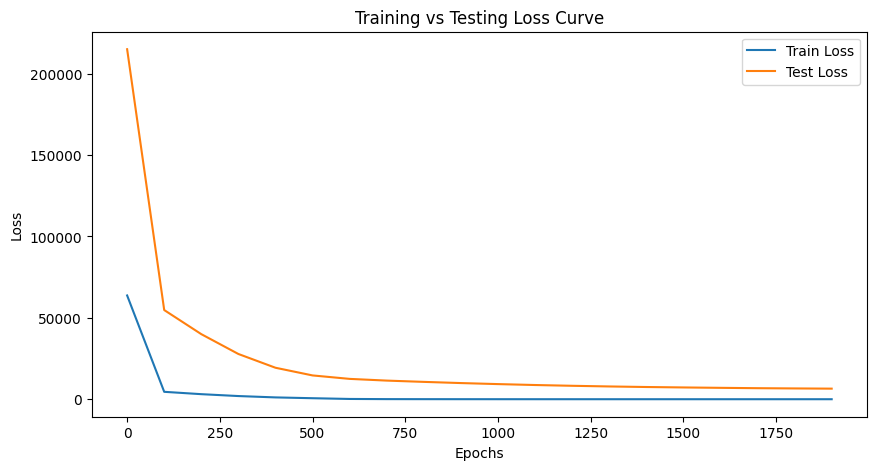

In [70]:
plt.figure(figsize=(10,5))

plt.plot(epoch_count, train_loss_values, label="Train Loss")
plt.plot(epoch_count, test_loss_values, label="Test Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Testing Loss Curve")
plt.legend()
plt.show()

Theory:
The trained model makes predictions on test data, and the results are visualized to evaluate how well the model fits the dataset.

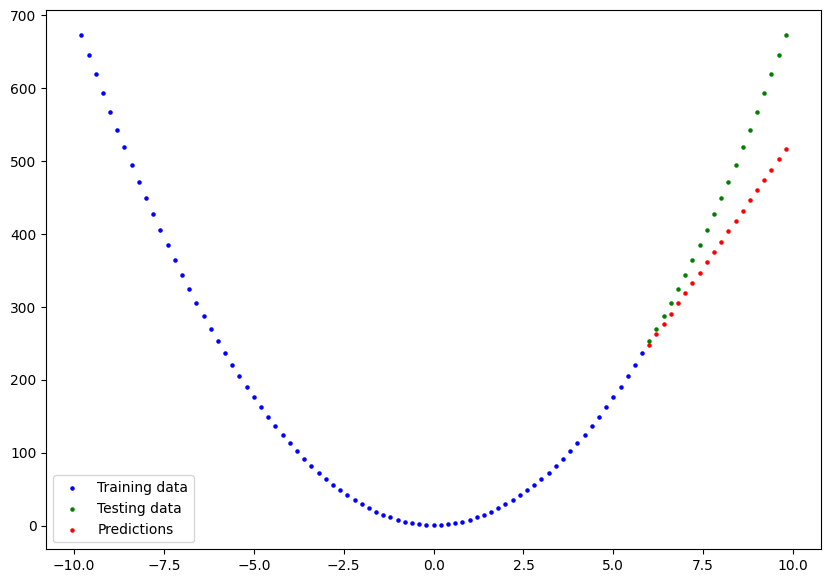

In [71]:
model.eval()

with torch.inference_mode():
    y_preds = model(X_test)

plot_predictions(predictions=y_preds)

Discussion and Conclusion

In the current lab assignment, Linear Regression was realized by means of PyTorch in order to forecast output values according to input values. The given data were split into training and testing datasets, and a machine-learning algorithm learned to estimate output values. In particular, during training, the loss value decreased, which proves that the model learned to predict output values based on the input variables. Prediction plots prove that after training, the prediction model fit the actual data better.

In the second part of this lab, an artificial neural network including several hidden layers was used to learn a more complicated pattern. The application of activation functions and Adam optimizer made the model better at forecasting because the given functions enabled the estimation of more complex relations between variables. In general, the current experiment has proved that PyTorch can be effectively used for building, training, and testing both linear and nonlinear regression models.